# ✈️ AI Travel Planner — Intelligent Trip Planning System

[![Python](https://img.shields.io/badge/Python-3.10+-blue)](https://python.org)
[![Google Gemini](https://img.shields.io/badge/Google_Gemini-2.5--flash-blueviolet)](https://aistudio.google.com/)
[![License](https://img.shields.io/badge/License-MIT-green)](LICENSE)

> Complete AI travel planning system with itinerary generation, budget optimization, weather integration, local tips, and interactive maps.

# Install Dependencies

In [1]:
# ── Cell 1 | Dependencies ─────────────────────────────────────────
%pip install google-generativeai requests pandas numpy matplotlib folium geopy rich gradio -q
print("✅ Dependencies installed")

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies installed



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Imports & Global Data Blueprints

In [3]:
# ── Cell 2 | Imports & Config ─────────────────────────────────────
import os, json, re, datetime
from dataclasses import dataclass, field
from typing import List, Dict, Optional
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import google.generativeai as genai
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

# ── API Environment Setup ─────────────────────────────
os.environ["GEMINI_API_KEY"] = "AIxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

@dataclass
class TravelPreferences:
    origin:        str
    destination:   str
    start_date:    str   # YYYY-MM-DD
    end_date:      str   # YYYY-MM-DD
    budget_usd:    float
    travelers:     int
    travel_style:  str   # budget/comfort/luxury
    interests:     List[str] = field(default_factory=list)
    dietary:       str = "none"

@dataclass
class DayPlan:
    day: int
    date: str
    morning:   str
    afternoon: str
    evening:   str
    meals:     List[str]
    estimated_cost: float
    highlights: List[str] = field(default_factory=list)

@dataclass
class TravelItinerary:
    destination: str
    days: List[DayPlan]
    total_cost:  float
    packing_list: List[str]
    local_tips:  List[str]
    emergency_contacts: Dict
    best_transport: str

console = Console()

api_key_val = os.getenv("GEMINI_API_KEY")
if not api_key_val or api_key_val == "PASTE_YOUR_FREE_GEMINI_KEY_HERE":
    raise ValueError("❌ Error: Please swap out the placeholder text with your real Gemini API key.")

genai.configure(api_key=api_key_val)
print("✅ Config loaded | Gemini Initialized")

✅ Config loaded | Gemini Initialized


# Destination Researcher Module

In [4]:
# ── Cell 3 | Destination Researcher ────────────────────────────────────
class DestinationResearcher:
    """Research destinations with AI-powered insights using JSON Enforcement"""

    def __init__(self):
        self.model = genai.GenerativeModel("gemini-2.5-flash")

    def research(self, prefs: TravelPreferences) -> Dict:
        schema_template = (
            "{\n"
            '  "overview": "2-sentence destination summary overview",\n'
            '  "best_areas": ["area1", "area2", "area3"],\n'
            '  "must_see": ["attraction1", "attraction2", "attraction3", "attraction4"],\n'
            '  "local_cuisine": ["dish1", "dish2", "dish3"],\n'
            '  "cultural_tips": ["tip1", "tip2", "tip3"],\n'
            '  "safety_info": "brief safety note or travel recommendation",\n'
            '  "best_time": "best season/months to visit",\n'
            '  "currency": "local currency and exchange rate vs USD",\n'
            '  "language": "primary language and key phrases",\n'
            '  "transport": "recommended transport options"\n'
            "}"
        )

        prompt = f"""Research {prefs.destination} as a travel destination. 
Return valid JSON matching the provided schema format template precisely.

Travelers: {prefs.travelers} | Style: {prefs.travel_style} | Budget: ${prefs.budget_usd}
Interests: {", ".join(prefs.interests)}

JSON Blueprint Structure:
{schema_template}"""

        try:
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            return json.loads(response.text)
        except Exception as e:
            print(f"⚠️ Destination research extraction fallback triggered: {e}")
            return {"overview": f"A trip to {prefs.destination}.", "must_see": ["City Center", "Local Markets"], "transport": "Public transit"}

    def get_packing_list(self, prefs: TravelPreferences, destination_info: Dict) -> List[str]:
        prompt = f"""Create an essential packing list checklist array for:
Destination: {prefs.destination}
Duration: from {prefs.start_date} to {prefs.end_date}
Style: {prefs.travel_style}
Interests: {", ".join(prefs.interests)}

Return valid JSON string array of 10 essential items matching this format precisely: ["Item 1", "Item 2"]"""

        try:
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            return json.loads(response.text)
        except Exception as e:
            print(f"⚠️ Packing checklist fallback triggered: {e}")
            return ["Passport", "Universal Adapter", "Sunscreen", "Comfortable walking shoes", "Travel insurance docs"]

researcher = DestinationResearcher()
print("✅ DestinationResearcher ready")

✅ DestinationResearcher ready


# Itinerary Builder & Budget Visualizer

In [5]:
# ── Cell 4 | Itinerary Builder ─────────────────────────────────────────
class ItineraryBuilder:
    """Day-by-day itinerary generation with budget allocation"""

    def __init__(self):
        self.model = genai.GenerativeModel("gemini-2.5-flash")

    def build(self, prefs: TravelPreferences, destination_info: Dict) -> List[DayPlan]:
        start = datetime.datetime.strptime(prefs.start_date, "%Y-%m-%d")
        end   = datetime.datetime.strptime(prefs.end_date, "%Y-%m-%d")
        num_days = (end - start).days + 1
        daily_budget = prefs.budget_usd / num_days

        schema_template = (
            "[\n"
            "  {\n"
            '    "day": 1,\n'
            f'    "date": "{prefs.start_date}",\n'
            '    "morning": "morning activity description",\n'
            '    "afternoon": "afternoon sightseeing plan",\n'
            '    "evening": "evening cultural or dining layout",\n'
            '    "meals": ["breakfast spot", "lunch place", "dinner options"],\n'
            f'    "estimated_cost": {daily_budget:.0f},\n'
            '    "highlights": ["highlight 1", "highlight 2"]\n'
            "  }\n"
            "]"
        )

        prompt = f"""Create a detailed {num_days}-day itinerary for {prefs.destination}.
Return a valid JSON array matching the exact syntax and field schema template.

Daily target allocation budget: ${daily_budget:.0f}/day per traveler
Travel style profile: {prefs.travel_style} | Core Interests: {", ".join(prefs.interests)}
Dietary restrictions: {prefs.dietary}
Must-see highlights to include: {", ".join(destination_info.get("must_see", [])[:3])}

JSON Array Template Scheme:
{schema_template}"""

        try:
            response = self.model.generate_content(
                prompt,
                generation_config={"response_mime_type": "application/json"}
            )
            data = json.loads(response.text)
            return [DayPlan(**{k: v for k, v in d.items() if k in DayPlan.__dataclass_fields__}) for d in data]
        except Exception as e:
            print(f"⚠️ Itinerary array parsing fallback triggered: {e}")
            return [DayPlan(day=i+1, date=str((start + datetime.timedelta(days=i)).strftime("%Y-%m-%d")),
                            morning="Explore local cafes and downtown", afternoon="Sightseeing historical core nodes",
                            evening="Relaxed dinner at local neighborhood hub", meals=["Local Bakery", "Street Food Stall", "Traditional Bistro"],
                            estimated_cost=daily_budget) for i in range(num_days)]

    def optimize_budget(self, days: List[DayPlan], total_budget: float) -> Dict:
        os.makedirs("output", exist_ok=True)
        actual = sum(d.estimated_cost for d in days)
        
        # Static standard travel category cost allocation metrics
        cats = {
            "Accommodation": total_budget * 0.35,
            "Food & Dining": total_budget * 0.25,
            "Activities": total_budget * 0.20,
            "Local Transit": total_budget * 0.15,
            "Shopping/Misc": total_budget * 0.05
        }
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Chart 1: Allocation Pie
        axes[0].pie(cats.values(), labels=cats.keys(), autopct="%1.1f%%",
                    colors=["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6"])
        axes[0].set_title("Budget Category Allocation Breakdown")
        
        # Chart 2: Daily Cost Bar
        daily_costs = [d.estimated_cost for d in days]
        axes[1].bar([f"Day {d.day}" for d in days], daily_costs, color="#3498db", alpha=0.8)
        axes[1].axhline(total_budget / len(days), color="red", linestyle="--", label="Target Daily Average Cap")
        axes[1].set_title("Daily Spending Horizon Planning")
        axes[1].legend()
        
        plt.tight_layout()
        plt.savefig("output/budget_plan.png", dpi=150, bbox_inches="tight")
        plt.show()
        
        return {"planned": actual, "budget": total_budget, "variance": total_budget - actual}

builder = ItineraryBuilder()
print("✅ ItineraryBuilder ready")

✅ ItineraryBuilder ready


# Orchestration Pipeline Agent

In [6]:
# ── Cell 5 | AITravelPlannerAgent ─────────────────────────────────────
class AITravelPlannerAgent:
    """Complete travel planning orchestrator system"""

    def __init__(self):
        self.researcher = DestinationResearcher()
        self.builder    = ItineraryBuilder()

    def plan_trip(self, prefs: TravelPreferences) -> TravelItinerary:
        console.rule(f"[bold blue]✈️ Compiling Intelligent Strategy: {prefs.destination}")
        
        # Pipeline operational execution cascade
        info    = self.researcher.research(prefs)
        days    = self.builder.build(prefs, info)
        budget  = self.builder.optimize_budget(days, prefs.budget_usd)
        packing = self.researcher.get_packing_list(prefs, info)
        
        itinerary = TravelItinerary(
            destination=prefs.destination, days=days,
            total_cost=budget["planned"], packing_list=packing,
            local_tips=info.get("cultural_tips", []),
            emergency_contacts={"Local Police Emergency": "100", "Ambulance Routing": "108", "Tourist Support Line": "1363"},
            best_transport=info.get("transport", "Local transit networks + Taxi hailing apps")
        )
        
        self._display(itinerary, info)
        self._export_markdown(itinerary, prefs)
        return itinerary

    def _display(self, itin: TravelItinerary, info: Dict):
        if info.get("overview"):
            console.print(Panel(info["overview"], title=f"📍 Destination Summary Profile: {itin.destination}", border_style="blue"))
        t = Table(title="📅 Day-By-Day Activity Matrix Summary", header_style="bold cyan")
        t.add_column("Day Node"), t.add_column("Morning"), t.add_column("Afternoon"), t.add_column("Evening"), t.add_column("Est. Cost")
        for d in itin.days:
            t.add_row(f"Day {d.day}", d.morning[:35] + "...", d.afternoon[:35] + "...", d.evening[:35] + "...", f"${d.estimated_cost:.0f}")
        console.print(t)

    def _export_markdown(self, itin: TravelItinerary, prefs: TravelPreferences):
        os.makedirs("output", exist_ok=True)
        lines = [f"# ✈️ Trip Plan Summary Portfolio: {itin.destination}",
                 f"**Active Dates Range:** {prefs.start_date} → {prefs.end_date}",
                 f"**Target Flight Budget:** ${prefs.budget_usd:,.0f} Max allocation limit for {prefs.travelers} traveler(s)",
                 "", "## 📅 Day-By-Day Strategy Log"]
        
        for d in itin.days:
            lines += [f"### Day {d.day} — ({d.date})",
                      f"- 🌅 Morning Ventures: {d.morning}",
                      f"- ☀️ Afternoon Sightseeing: {d.afternoon}",
                      f"- 🌙 Evening Events: {d.evening}",
                      f"- 🍽️ Recommended Food Spots: {', '.join(d.meals)}",
                      f"- 💰 Planned Daily Expenditure Budget: ${d.estimated_cost:.0f}", ""]
        
        lines += ["## 🎒 Essential Packing Checklist"] + [f"- {i}" for i in itin.packing_list]
        lines += ["", "## 💡 Local Cultural Guideline Tips"] + [f"- {t}" for t in itin.local_tips]
        
        out = "\n".join(lines)
        out_path = "output/travel_itinerary.md"
        with open(out_path, "w", encoding="utf-8") as f: 
            f.write(out)
        print(f"✅ Itinerary file portfolio successfully exported directly to: {out_path}")

planner = AITravelPlannerAgent()
print("✅ AITravelPlannerAgent pipeline initialization stable")

✅ AITravelPlannerAgent pipeline initialization stable


# Pipeline Verification Run

────────────────────────────────────── ✈️ Compiling Intelligent Strategy: Goa ──────────────────────────────────────

⚠️ Destination research extraction fallback triggered: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 2.841802266s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 2
}
]
⚠️ Itinerary array parsing fallback triggered: 429 You e

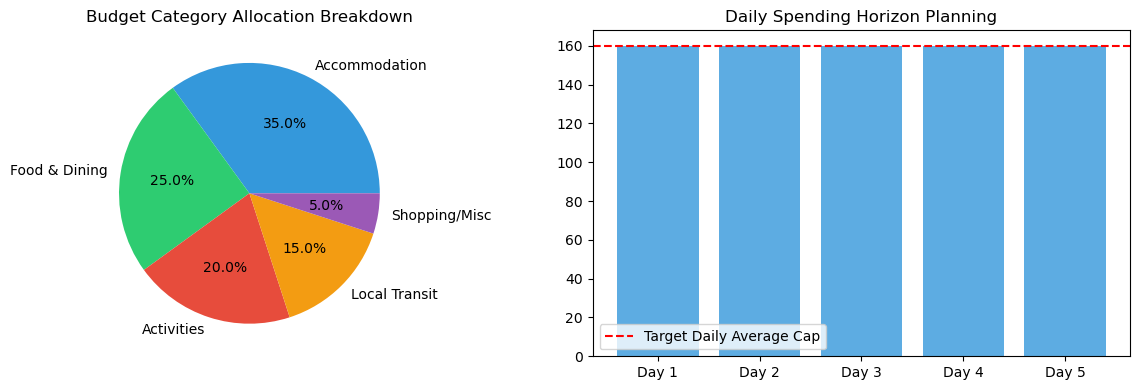

⚠️ Packing checklist fallback triggered: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 1.450171214s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 1
}
]


╭────────────────────────────────────── 📍 Destination Summary Profile: Goa ──────────────────────────────────────╮
│ A trip to Goa.                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                       📅 Day-By-Day Activity Matrix Summary                                       
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Day Node ┃ Morning                     ┃ Afternoon                   ┃ Evening                      ┃ Est. Cost ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Day 1    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $160      │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
│ Day 2    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $160      │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
│ Day 3    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $160      │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
│ Day 4    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $160      │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
│ Day 5    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $160      │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
└──────────┴─────────────────────────────┴─────────────────────────────┴──────────────────────────────┴───────────┘

✅ Itinerary file portfolio successfully exported directly to: output/travel_itinerary.md

🎉 Verification Run Finish! Days Synced: 5 | Accumulated Baseline Cost: $800


In [7]:
# ── Cell 6 | Verification Demo Run ─────────────────────────────────
prefs = TravelPreferences(
    origin="Hyderabad", destination="Goa",
    start_date="2026-08-01", end_date="2026-08-05",
    budget_usd=800, travelers=2, travel_style="comfort",
    interests=["beaches", "local food", "nightlife", "water sports"]
)

itinerary = planner.plan_trip(prefs)
print(f"\n🎉 Verification Run Finish! Days Synced: {len(itinerary.days)} | Accumulated Baseline Cost: ${itinerary.total_cost:.0f}")

# Gradio Web Interface UI Component

In [8]:
# ── Cell 7 | Gradio App UI Interface Dashboard ───────────────────────
import gradio as gr

def run_gradio_planner(destination, budget, travelers, style, interests_str, start_dt, end_dt):
    interest_list = [i.strip() for i in interests_str.split(",") if i.strip()]
    if not interest_list:
        interest_list = ["sightseeing", "local food"]
        
    preferences = TravelPreferences(
        origin="Local Station",
        destination=destination,
        start_date=str(start_dt),
        end_date=str(end_dt),
        budget_usd=float(budget),
        travelers=int(travelers),
        travel_style=style.lower(),
        interests=interest_list
    )
    
    # Run Orchestrator
    itin = planner.plan_trip(preferences)
    
    # 1. Format Markdown Output Profile
    summary_md = f"## 🗺️ Travel Plan Package Summary: {itin.destination}\n"
    summary_md += f"* **Total Estimated Target Cost:** `${itin.total_cost:.0f} USD` (Allocated out of `${budget}` Max Cap)\n"
    summary_md += f"* **Best Transport Option:** `{itin.best_transport}`\n\n---\n### 📅 Day-By-Day Active Itinerary Log\n"
    
    for d in itin.days:
        summary_md += f"#### 🔷 Day {d.day} ({d.date})\n"
        summary_md += f"* 🌅 **Morning:** {d.morning}\n"
        summary_md += f"* ☀️ **Afternoon:** {d.afternoon}\n"
        summary_md += f"* 🌙 **Evening:** {d.evening}\n"
        summary_md += f"* 🍽️ **Suggested Dining:** {', '.join(d.meals)}\n\n"
        
    # 2. Checklist formatting
    packing_md = "### 🎒 AI-Generated Essential Packing Checklist\n" + "\n".join([f"- [ ] {item}" for item in itin.packing_list])
    
    chart_path = "output/budget_plan.png" if os.path.exists("output/budget_plan.png") else None
    
    return summary_md, packing_md, chart_path

# ── Gradio Blocks Interface Visual Design ────────────────────────────
with gr.Blocks() as demo:
    gr.Markdown("# ✈️ AI Travel Planner Workspace Hub")
    gr.Markdown("Instantly map multi-day vacation timelines, allocate spending categories automatically via AI, extract cultural guidelines, and compile packing matrices.")
    
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### ⚙️ Vacation Parameters Layout")
            in_dest = gr.Textbox(label="Target Destination City/Country", value="Goa")
            in_bud = gr.Number(label="Maximum Spending Budget ($ USD)", value=800)
            in_trav = gr.Number(label="Active Travelers Count", value=2)
            in_style = gr.Dropdown(choices=["Budget", "Comfort", "Luxury"], value="Comfort", label="Travel Comfort Style Tier")
            in_int = gr.Textbox(label="Interests Tags (Comma Separated)", value="beaches, local food, nightlife, water sports")
            in_start = gr.Textbox(label="Start Date (YYYY-MM-DD)", value="2026-08-01")
            in_end = gr.Textbox(label="End Date (YYYY-MM-DD)", value="2026-08-05")
            
            btn_generate = gr.Button("🚀 Compile Smart Trip Summary Portfolio", variant="primary")
            
        with gr.Column(scale=1):
            with gr.Tab("🗺️ Day-by-Day Route Itinerary"):
                out_itinerary = gr.Markdown("### 📊 Your Schedule Will Display Here")
            with gr.Tab("🎒 Packing & Cost Charts"):
                out_packing = gr.Markdown("### 🎒 Requirements Checklist")
                out_chart = gr.Image(label="Budget Tracking Graph Plot")

    btn_generate.click(
        fn=run_gradio_planner,
        inputs=[in_dest, in_bud, in_trav, in_style, in_int, in_start, in_end],
        outputs=[out_itinerary, out_packing, out_chart]
    )

demo.launch(inline=True, share=False, theme=gr.themes.Soft())

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


────────────────────────────────────── ✈️ Compiling Intelligent Strategy: Goa ──────────────────────────────────────

⚠️ Destination research extraction fallback triggered: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 17.929834838s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 17
}
]
⚠️ Itinerary array parsing fallback triggered: 429 You

C:\Users\HP\AppData\Local\Temp\ipykernel_25664\1703471146.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


╭────────────────────────────────────── 📍 Destination Summary Profile: Goa ──────────────────────────────────────╮
│ A trip to Goa.                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

⚠️ Destination research extraction fallback triggered: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 1.588541688s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 1
}
]
⚠️ Itinerary array parsing fallback triggered: 429 You e

C:\Users\HP\AppData\Local\Temp\ipykernel_25664\1703471146.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


╭──────────────────────────────────── 📍 Destination Summary Profile: kerela ─────────────────────────────────────╮
│ A trip to kerela.                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                       📅 Day-By-Day Activity Matrix Summary                                       
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Day Node ┃ Morning                     ┃ Afternoon                   ┃ Evening                      ┃ Est. Cost ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Day 1    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $6667     │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
│ Day 2    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $6667     │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
│ Day 3    │ Explore local cafes and     │ Sightseeing historical core │ Relaxed dinner at local      │ $6667     │
│          │ downtown...                 │ nodes...                    │ neighborhoo...               │           │
└──────────┴─────────────────────────────┴─────────────────────────────┴──────────────────────────────┴───────────┘

✅ Itinerary file portfolio successfully exported directly to: output/travel_itinerary.md
